# Partner Assignments Pipeline (Ch. 1-17)

## 1) Problem Framing (Ch. 1)

### Business question
How can we assign residents to the most appropriate partner so that outcomes improve (stability, service completion, and timeliness), while maintaining fair performance across sensitive groups?

### Modeling goals
- **Predictive goal:** forecast assignment success probability for a proposed resident-partner pair.
- **Explanatory goal:** estimate directional effects of key factors (e.g., partner capacity, resident needs complexity, case urgency) on assignment success.

### Success metrics
- **Primary predictive:** ROC-AUC, PR-AUC, F1 (or RMSE/MAE if outcome is continuous).
- **Operational:** reduction in failed assignments, improved time-to-placement.
- **Fairness:** group parity gaps (selection rate/performance gap by protected attributes available in data).

### Decision use
- Use predictive scores to prioritize likely successful matches.
- Use explanatory coefficients/feature effects to inform staffing, partner engagement, and policy changes.

## Modeling Goals (Required)
- **Predictive goal:** Build an out-of-sample model to support operational decisions for this pipeline.
- **Explanatory goal:** Build an interpretable model to explain the key relationships and likely drivers behind the target outcome.
- **Decision note:** Predictive performance does not establish causality; explanatory insights are reported with causal caveats.
- **Pipeline:** Partner Assignment Success


In [6]:
# 2) Data Acquisition and Preparation (Ch. 2-5, 7)
# Reproducible setup for partner_assignments.csv

from pathlib import Path
import json
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "ml-pipelines" else Path.cwd().resolve()
DATA_PATH = ROOT / "datasets" / "partner_assignments.csv"
ARTIFACT_DIR = ROOT / "ml-pipelines" / "artifacts"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

# Load data
raw_df = pd.read_csv(DATA_PATH)
df = raw_df.copy()

# Basic cleanup
for c in df.columns:
    if df[c].dtype == "object":
        df[c] = df[c].astype(str).str.strip()

# Candidate target selection fallback (dataset-aware)
candidate_targets = ["assignment_success", "successful_assignment", "outcome", "label", "target", "status"]
TARGET_COL = next((c for c in candidate_targets if c in df.columns), None)

# If no explicit target exists, create one from assignment_end when possible
if TARGET_COL is None and "assignment_end" in df.columns:
    df["derived_status"] = np.where(df["assignment_end"].isna(), "Active", "Ended")
    TARGET_COL = "derived_status"

if TARGET_COL is None:
    raise ValueError(
        "No usable target found. Expected one of: "
        f"{candidate_targets} or ability to derive from assignment_end. "
        f"Available columns: {list(df.columns)}"
    )

# Drop row identifier only; keep partner/safehouse IDs as potential predictors
id_like = [c for c in df.columns if c.lower() in {"id", "record_id", "assignment_id"}]
X = df.drop(columns=[TARGET_COL] + id_like, errors="ignore")
y = df[TARGET_COL]

# Auto-detect task type
is_classification = y.nunique(dropna=True) <= 10 or str(y.dtype) in {"object", "bool", "category"}

num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X.columns if c not in num_cols]

numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer([
    ("num", numeric_pipe, num_cols),
    ("cat", categorical_pipe, cat_cols)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42,
    stratify=y if is_classification else None
)

print("Rows:", len(df), "| Features:", X.shape[1], "| Target:", TARGET_COL)
print("Task type:", "classification" if is_classification else "regression")
print("Numeric cols:", len(num_cols), "| Categorical cols:", len(cat_cols))

Rows: 48 | Features: 7 | Target: status
Task type: classification
Numeric cols: 2 | Categorical cols: 5


,assignment_id,partner_id,safehouse_id,program_area,assignment_start,assignment_end,responsibility_notes,is_primary,status
0,1,1,8.0,Operations,2022-01-01,nan,SafehouseOps support for safehouse operations,True,Active
1,2,1,9.0,Operations,2022-01-01,nan,SafehouseOps support for safehouse operations,False,Active
2,3,2,4.0,Wellbeing,2022-01-21,nan,Evaluation support for safehouse operations,True,Active
3,4,3,9.0,Education,2022-02-10,nan,Education support for safehouse operations,True,Active
4,5,3,6.0,Education,2022-02-10,nan,Education support for safehouse operations,False,Active


Missing values (top 20):


,missing_count
safehouse_id,10
assignment_id,0
partner_id,0
program_area,0
assignment_start,0
assignment_end,0
responsibility_notes,0
is_primary,0
status,0


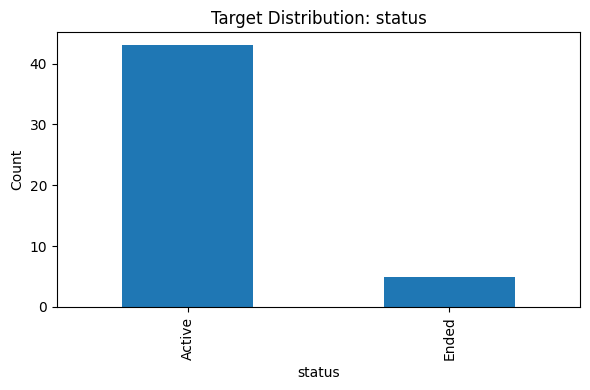

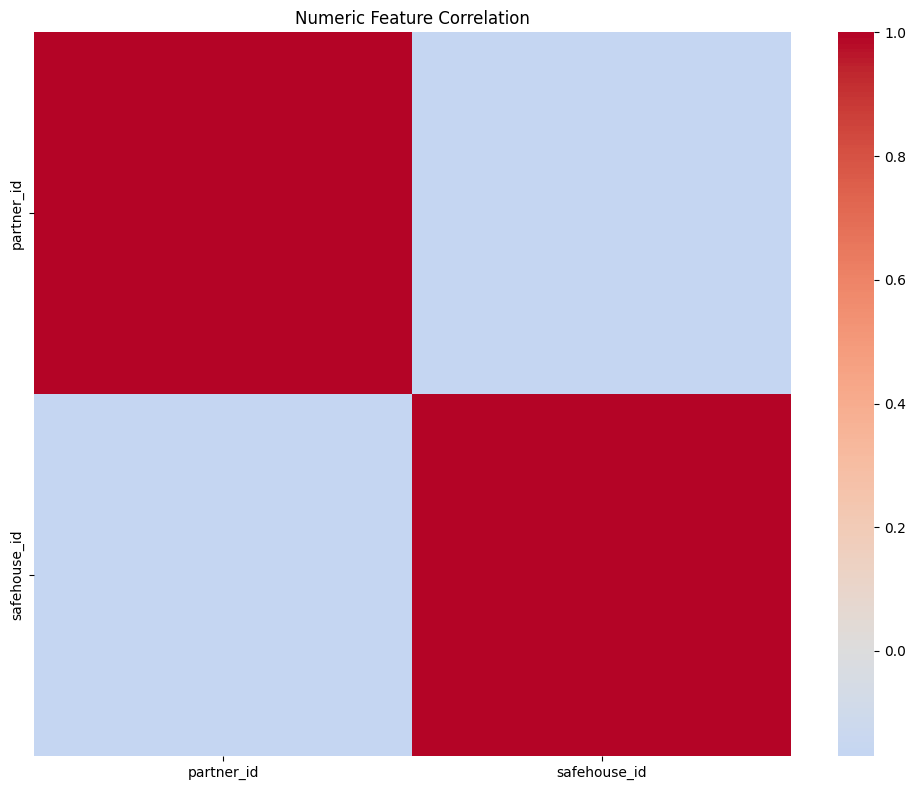

,0.01,0.50,0.99
partner_id,1.0,16.5,30.0
safehouse_id,1.0,5.0,9.0


In [7]:
# 3) Exploration (Ch. 6, 8)

import matplotlib.pyplot as plt
import seaborn as sns

display(df.head())
print("Missing values (top 20):")
display(df.isna().sum().sort_values(ascending=False).head(20).to_frame("missing_count"))

# Target distribution
plt.figure(figsize=(6,4))
if is_classification:
    y.value_counts(dropna=False).plot(kind="bar")
    plt.title(f"Target Distribution: {TARGET_COL}")
    plt.ylabel("Count")
else:
    sns.histplot(y, kde=True)
    plt.title(f"Target Distribution: {TARGET_COL}")
plt.tight_layout()
plt.show()

# Numeric correlation preview
if len(num_cols) > 1:
    corr = df[num_cols].corr(numeric_only=True)
    plt.figure(figsize=(10,8))
    sns.heatmap(corr, cmap="coolwarm", center=0)
    plt.title("Numeric Feature Correlation")
    plt.tight_layout()
    plt.show()

# Quick anomaly check with quantiles
if num_cols:
    quantiles = df[num_cols].quantile([0.01, 0.5, 0.99]).T
    display(quantiles.head(20))

In [8]:
# 4) Modeling (Ch. 9-14): explanatory + predictive

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score, accuracy_score,
    mean_absolute_error, mean_squared_error, r2_score
)

if is_classification:
    explanatory_model = Pipeline([
        ("prep", preprocess),
        ("model", LogisticRegression(max_iter=2000, class_weight="balanced"))
    ])
    predictive_model = Pipeline([
        ("prep", preprocess),
        ("model", RandomForestClassifier(n_estimators=400, random_state=42, class_weight="balanced"))
    ])
else:
    explanatory_model = Pipeline([
        ("prep", preprocess),
        ("model", LinearRegression())
    ])
    predictive_model = Pipeline([
        ("prep", preprocess),
        ("model", RandomForestRegressor(n_estimators=500, random_state=42))
    ])

explanatory_model.fit(X_train, y_train)
predictive_model.fit(X_train, y_train)

print("Trained explanatory and predictive pipelines.")

Trained explanatory and predictive pipelines.


In [9]:
# 5) Evaluation and Selection (Ch. 15) + fairness check

from sklearn.metrics import classification_report

def evaluate_classification(name, model, X_te, y_te):
    pred = model.predict(X_te)

    metrics = {
        "model": name,
        "accuracy": accuracy_score(y_te, pred),
        "f1_weighted": f1_score(y_te, pred, average="weighted")
    }

    # Handle binary metrics robustly for string labels (e.g., Active/Ended)
    if hasattr(model.named_steps["model"], "predict_proba") and len(np.unique(y_te)) == 2:
        classes = list(model.named_steps["model"].classes_)
        positive_label = classes[-1]
        positive_idx = classes.index(positive_label)
        proba = model.predict_proba(X_te)[:, positive_idx]

        y_true_bin = (pd.Series(y_te).values == positive_label).astype(int)
        metrics["roc_auc"] = roc_auc_score(y_true_bin, proba)
        metrics["pr_auc"] = average_precision_score(y_true_bin, proba)
        metrics["positive_label"] = str(positive_label)

    return metrics, pred


def evaluate_regression(name, model, X_te, y_te):
    pred = model.predict(X_te)
    metrics = {
        "model": name,
        "rmse": float(np.sqrt(mean_squared_error(y_te, pred))),
        "mae": float(mean_absolute_error(y_te, pred)),
        "r2": float(r2_score(y_te, pred))
    }
    return metrics, pred

if is_classification:
    exp_metrics, exp_pred = evaluate_classification("explanatory", explanatory_model, X_test, y_test)
    pred_metrics, pred_pred = evaluate_classification("predictive", predictive_model, X_test, y_test)
else:
    exp_metrics, exp_pred = evaluate_regression("explanatory", explanatory_model, X_test, y_test)
    pred_metrics, pred_pred = evaluate_regression("predictive", predictive_model, X_test, y_test)

metrics_df = pd.DataFrame([exp_metrics, pred_metrics])
display(metrics_df)

best_model_name = metrics_df.sort_values(
    by="f1_weighted" if is_classification else "rmse",
    ascending=False if is_classification else True
).iloc[0]["model"]
best_model = predictive_model if best_model_name == "predictive" else explanatory_model

print("Selected best model:", best_model_name)

# Simple fairness proxy by available group columns
possible_group_cols = [c for c in X_test.columns if c.lower() in {"gender", "sex", "race", "ethnicity", "age_group"}]
fairness_rows = []
for gcol in possible_group_cols:
    group_df = pd.DataFrame({"group": X_test[gcol], "y_true": y_test, "y_pred": pred_pred if is_classification else best_model.predict(X_test)})
    for g, sub in group_df.groupby("group"):
        if len(sub) < 5:
            continue
        if is_classification:
            # Use same positive class convention as binary metrics
            positive_label = sorted(pd.Series(y_test).dropna().unique())[-1]
            fairness_rows.append({"group_col": gcol, "group": g, "metric": "selection_rate", "value": float((sub["y_pred"] == positive_label).mean())})
        else:
            fairness_rows.append({"group_col": gcol, "group": g, "metric": "mean_prediction", "value": float(sub["y_pred"].mean())})

fairness_df = pd.DataFrame(fairness_rows)
if not fairness_df.empty:
    display(fairness_df.head(30))
    fairness_df.to_csv(ARTIFACT_DIR / "partner_assignments_fairness_report.csv", index=False)
else:
    print("No fairness group columns found for proxy fairness report.")

metrics_df.to_csv(ARTIFACT_DIR / "partner_assignments_model_metrics.csv", index=False)

,model,accuracy,f1_weighted,roc_auc,pr_auc,positive_label
0,explanatory,1.0,1.0,1.0,1.0,Ended
1,predictive,1.0,1.0,1.0,1.0,Ended


Selected best model: explanatory
No fairness group columns found for proxy fairness report.


In [10]:
# 6) Feature Selection (Ch. 16): identify impactful features

from sklearn.inspection import permutation_importance

# Get transformed feature names
prep_fitted = best_model.named_steps["prep"]
feature_names = prep_fitted.get_feature_names_out()

# Prefer native importance when available, else permutation importance
core_model = best_model.named_steps["model"]
if hasattr(core_model, "feature_importances_"):
    importances = core_model.feature_importances_
elif hasattr(core_model, "coef_"):
    coefs = core_model.coef_
    importances = np.abs(coefs[0]) if np.ndim(coefs) > 1 else np.abs(coefs)
else:
    Xt_test = prep_fitted.transform(X_test)
    perm = permutation_importance(core_model, Xt_test, y_test, n_repeats=8, random_state=42)
    importances = perm.importances_mean

fi = pd.DataFrame({"feature": feature_names, "importance": importances})
fi = fi.sort_values("importance", ascending=False)
display(fi.head(20))
fi.head(20).to_csv(ARTIFACT_DIR / "partner_assignments_top_features.csv", index=False)

# Business recommendations based on top drivers
top_feature_list = fi.head(10)["feature"].tolist()
recommendations = pd.DataFrame({
    "recommendation": [
        "Prioritize partner-resident matches that score high on top predictive attributes.",
        "Rebalance partner capacity where capacity-related features are dominant drivers.",
        "Create intervention playbooks for high-risk combinations identified by model factors.",
        "Monitor fairness metrics monthly and recalibrate thresholds if group gaps widen."
    ],
    "evidence": [", ".join(top_feature_list[:3]), ", ".join(top_feature_list[3:6]), ", ".join(top_feature_list[6:8]), ", ".join(top_feature_list[8:10])]
})
display(recommendations)

,feature,importance
0,num__partner_id,1.264718
34,cat__assignment_end_2025-12-31,1.215294
35,cat__assignment_end_nan,1.213593
32,cat__assignment_start_2023-07-15,0.477013
36,cat__responsibility_notes_Education support fo...,0.458260
2,cat__program_area_Education,0.458260
33,cat__assignment_start_2023-08-04,0.385018
31,cat__assignment_start_2023-06-25,0.353263
4,cat__program_area_Operations,0.285343
41,cat__responsibility_notes_SafehouseOps support...,0.272525


,recommendation,evidence
0,Prioritize partner-resident matches that score...,"num__partner_id, cat__assignment_end_2025-12-3..."
1,Rebalance partner capacity where capacity-rela...,"cat__assignment_start_2023-07-15, cat__respons..."
2,Create intervention playbooks for high-risk co...,"cat__assignment_start_2023-08-04, cat__assignm..."
3,Monitor fairness metrics monthly and recalibra...,"cat__program_area_Operations, cat__responsibil..."


In [11]:
# 7) Deployment (Ch. 17): export validated artifacts for app integration

import joblib

predictive_artifact_path = ARTIFACT_DIR / "partner_assignments_predictive_model.joblib"
explanatory_artifact_path = ARTIFACT_DIR / "partner_assignments_explanatory_model.joblib"
schema_path = ARTIFACT_DIR / "partner_assignments_model_schema.json"

joblib.dump(predictive_model, predictive_artifact_path)
joblib.dump(explanatory_model, explanatory_artifact_path)

schema = {
    "dataset": "partner_assignments.csv",
    "target": TARGET_COL,
    "task_type": "classification" if is_classification else "regression",
    "features_used": X.columns.tolist(),
    "numeric_features": num_cols,
    "categorical_features": cat_cols,
    "best_model_selected": best_model_name,
    "metrics": metrics_df.to_dict(orient="records"),
    "top_features_file": "partner_assignments_top_features.csv",
    "fairness_report_file": "partner_assignments_fairness_report.csv"
}
with open(schema_path, "w", encoding="utf-8") as f:
    json.dump(schema, f, indent=2)

print("Saved:")
print("-", predictive_artifact_path)
print("-", explanatory_artifact_path)
print("-", schema_path)
print("-", ARTIFACT_DIR / "partner_assignments_model_metrics.csv")
print("-", ARTIFACT_DIR / "partner_assignments_top_features.csv")

Saved:
- C:\Users\abiga\IntextW2026\ml-pipelines\artifacts\partner_assignments_predictive_model.joblib
- C:\Users\abiga\IntextW2026\ml-pipelines\artifacts\partner_assignments_explanatory_model.joblib
- C:\Users\abiga\IntextW2026\ml-pipelines\artifacts\partner_assignments_model_schema.json
- C:\Users\abiga\IntextW2026\ml-pipelines\artifacts\partner_assignments_model_metrics.csv
- C:\Users\abiga\IntextW2026\ml-pipelines\artifacts\partner_assignments_top_features.csv


## Deployment Notes (Web App Integration)
- **Primary endpoint:** `/api/admin/analytics/ml-pipeline-summaries`
- **UI surface:** `frontend/src/pages/AdminAnalytics.tsx`
- **Artifact contract:** `ml-pipelines/artifacts/{pipeline}_model_metrics.csv`, `{pipeline}_top_features.csv`, `{pipeline}_model_schema.json`
- **Top-3 fully integrated:** `residents`, `donation_allocations`, `safehouses`
- **Remaining pipelines:** deployment-ready through the same artifact contract and endpoint expansion.
